## Setup and Imports

In [2]:
# Standard imports
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyabf
import os
import pickle

# Add scripts to path
sys.path.append('../scripts')

# Import analysis functions
from utils import load_cell_metadata, load_trace_names, DEFAULT_PARENT_PATH
from waveforms import make_sheets_dict, add_abfs, sheets_to_waveforms
from spike_analysis import split_cell_attached, calculate_spike_statistics
from vrb_analysis import extract_bout_windows, plot_both_channels

# Set plotting style
plt.style.use('default')
%matplotlib inline

## 1. Configure Paths

In [3]:
# Update this to your local path
parent_folder_path = "/Users/Haley/Desktop/"
parent_folder_path_ABFS = "/Users/Haley/Desktop/ABF files annotated"

print(f"Project folder: {parent_folder_path}murray-neuroscience-lab/")
print(f"ABF files folder: {parent_folder_path_ABFS}")

Project folder: /Users/Haley/Desktop/murray-neuroscience-lab/
ABF files folder: /Users/Haley/Desktop/ABF files annotated


## 2. Load Cell Metadata and Annotations

In [4]:
# Load cell metadata (cell types, resistance, spiking stats)
cell_types_df = pd.read_csv(
    os.path.join(parent_folder_path,
                 "murray-neuroscience-lab/data/annotations/summary_spikes2.csv")
)

cell_types_df.reset_index(drop=True, inplace=True)
sheet_names = cell_types_df["Cell"].unique()

print(f"Loaded metadata for {len(sheet_names)} cells")
cell_types_df.head()

Loaded metadata for 32 cells


,Cell,currents,vrb,group,cell attached,Cell Type,Input Resistance,mean,median,min,max,total spikes,tags
0,2012_08_01_cell1,0,1,Low Rin Secondary,NaN,vSMN,287.00,24.97,24.52,18.47,38.55,41,yes
1,2012_08_01_cell3,0,1,Primary,NaN,MiP,49.99,42.55,42.84,29.46,52.69,65,yes
2,2012_08_07,0,1,Low Rin Secondary,NaN,vSMN,219.00,24.88,28.92,0.38,38.93,81,no
3,2012_08_31_cell1,1,2,Primary,NaN,MiP,45.33,39.28,38.40,26.93,52.55,64,yes
4,2012_08_31_cell2,0,2,Primary,NaN,vRoP,44.77,38.21,39.15,24.64,48.71,69,yes


In [5]:
# Load ABF trace names
abfs_names = pd.read_csv(
    os.path.join(parent_folder_path,
                 "murray-neuroscience-lab/data/annotations/all_trace_names.csv"),
    header=None
)
abfs_names = abfs_names.iloc[:, 0].to_numpy()

print(f"Found {len(abfs_names)} ABF traces")

Found 242 ABF traces


## 3. Create Annotation Sheets Dictionary

In [6]:
# Load annotation sheets with cell metadata
sheets = make_sheets_dict(sheet_names, parent_folder_path, cell_types_df)

print(f"Loaded {len(sheets)} annotation sheets")
print(f"\nSheet names: {list(sheets.keys())[:5]}...")  # Show first 5

Loaded 32 annotation sheets

Sheet names: ['2012_08_01_cell1', '2012_08_01_cell3', '2012_08_07', '2012_08_31_cell1', '2012_08_31_cell2']...


## 4. Associate ABF Files with Annotations

In [7]:
# Add ABF file objects to sheets
sheets = add_abfs(sheets, abfs_names, parent_folder_path_ABFS)

# Check structure
example_sheet = list(sheets.keys())[0]
print(f"Example sheet structure for '{example_sheet}':")
print(f"  - Has 'annotations': {('annotations' in sheets[example_sheet])}")
print(f"  - Has 'abfs': {('abfs' in sheets[example_sheet])}")
if 'abfs' in sheets[example_sheet]:
    print(f"  - Number of ABF files: {len(sheets[example_sheet]['abfs'])}")

Example sheet structure for '2012_08_01_cell1':
  - Has 'annotations': True
  - Has 'abfs': True
  - Number of ABF files: 9


## 5. Example: Visualize a Recording

Visualizing: 2012_08_01_cell1 - 2012_08_01_0009


/Users/Haley/Desktop/murray-neuroscience-lab/analysis/notebooks/../scripts/vrb_analysis.py:170: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/Users/Haley/Desktop/murray-neuroscience-lab/analysis/notebooks/../scripts/vrb_analysis.py:180: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


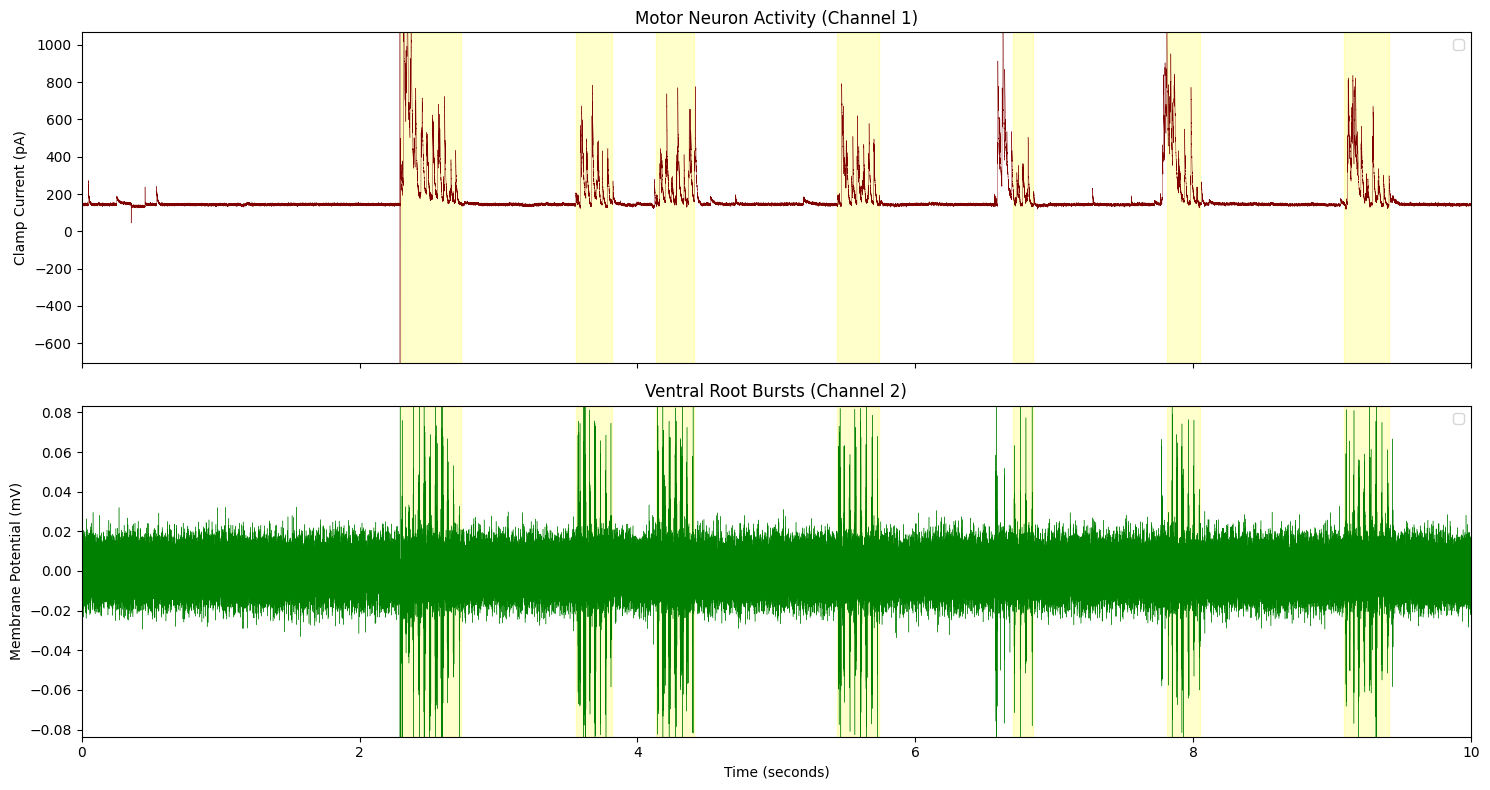

In [8]:
# Pick a cell and trace to visualize
example_cell = list(sheets.keys())[0]
example_abf_name = list(sheets[example_cell]['abfs'].keys())[0]
example_abf = sheets[example_cell]['abfs'][example_abf_name]
example_annotations = sheets[example_cell]['annotations'][
    sheets[example_cell]['annotations']['Trace name'] == example_abf_name
]

print(f"Visualizing: {example_cell} - {example_abf_name}")

# Plot both channels with bout markers
fig = plot_both_channels(example_abf, example_annotations, xlim=(0, 10))
plt.show()

## 6. Extract Waveforms

In [8]:
# Extract waveforms from all sheets
# This may take several minutes depending on data size
print("Extracting waveforms from all cells...")
all_waveforms = sheets_to_waveforms(sheets)

print(f"\nExtracted waveforms from {len(all_waveforms)} cells")

# Count total waveforms
total_waveforms = sum(
    len(trace_waveforms)
    for cell_waveforms in all_waveforms.values()
    for trace_waveforms in cell_waveforms.values()
)
print(f"Total waveforms extracted: {total_waveforms}")

Extracting waveforms from all cells...
Processing 1/32: 2012_08_01_cell1 - 9 traces processed
Processing 2/32: 2012_08_01_cell3 - 12 traces processed
Processing 3/32: 2012_08_07 - 11 traces processed
Processing 4/32: 2012_08_31_cell1 - 7 traces processed
Processing 5/32: 2012_08_31_cell2 - 5 traces processed
Processing 6/32: 2012_08_31_cell3 - 7 traces processed
Processing 7/32: 2012_08_31_cell4 - 6 traces processed
Processing 8/32: 2012_10_04_cell1 - 1 traces processed
Processing 9/32: 2012_10_04_cell2 - 7 traces processed
Processing 10/32: 2012_12_03_cell1 - 7 traces processed
Processing 11/32: 2012_12_04_cell1 - 7 traces processed
Processing 12/32: 2012_12_04_cell2 - 3 traces processed
Processing 13/32: 2012_12_05_cell1 - 9 traces processed
Processing 14/32: 2012_12_05_cell3 - 8 traces processed
Processing 15/32: 2012_12_05_cell4 - 5 traces processed
Processing 16/32: 2012_12_06_cell1 - 6 traces processed
Processing 17/32: 2012_12_06_cell2 - 10 traces processed
Processing 18/32: 201

: 

## 7. Cell-Attached Spike Analysis

In [ ]:
# Split sheets by cell-attached recordings
cell_attached_sheets, non_cell_attached = split_cell_attached(sheets)

print(f"Cells with cell-attached recordings: {len(cell_attached_sheets)}")
print(f"Cells without cell-attached recordings: {len(non_cell_attached)}")

# Calculate spike statistics
spike_summary = calculate_spike_statistics(cell_attached_sheets, cell_types_df)
spike_summary

## 8. Save Processed Data

In [ ]:
# Save waveforms dictionary
output_dir = os.path.join(parent_folder_path, "murray-neuroscience-lab/data/processed")
os.makedirs(output_dir, exist_ok=True)

with open(os.path.join(output_dir, "all_waveforms.pkl"), "wb") as f:
    pickle.dump(all_waveforms, f)

# Save spike summary
spike_summary.to_csv(
    os.path.join(output_dir, "spike_summary_updated.csv"),
    index=False
)

print("Saved processed data to:", output_dir)

## 9. Summary Statistics

In [ ]:
# Summary by cell type
if "Cell Type" in spike_summary.columns:
    summary_by_type = spike_summary.groupby("Cell Type").agg({
        "median": ["mean", "std", "count"],
        "mean": ["mean", "std"],
        "Input Resistance": ["mean", "std"]
    })
    print("\nSummary by Cell Type:")
    print(summary_by_type)

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

spike_summary["median"].hist(bins=20, ax=axes[0])
axes[0].set_xlabel("Median Spike Frequency (Hz)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Median Spike Frequencies")

spike_summary["Input Resistance"].hist(bins=20, ax=axes[1])
axes[1].set_xlabel("Input Resistance (MΩ)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Input Resistance")

plt.tight_layout()
plt.show()

## Next Steps

From here you can:
- Analyze waveform characteristics (amplitude, duration, shape)
- Compare waveforms across cell types
- Correlate spike patterns with VRB timing
- Generate publication-ready figures
- Perform statistical tests between groups